In [ ]:
import warnings
warnings.filterwarnings('ignore')

###Before starting, what exactly are non linear models?
Non-linear regression algorithms are machine learning techniques used to model and predict non-linear relationships between input variables and target variables. These algorithms aim to capture complex patterns and interactions that cannot be effectively represented by a linear model.
LightGBM is one of them which we will be using today

In [ ]:
#Loading the dataset from Kaggle
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "creditcard.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mlg-ulb/creditcardfraud",
  file_path,
)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# Normalization Amount
from sklearn.preprocessing import StandardScaler
df['nAmount'] = StandardScaler().fit_transform(df['Amount'].values.reshape(-1,1))

In [ ]:
#and with that the time and ammount coloumn
df.drop(['Time','Amount'], axis=1, inplace=True)


In [ ]:
y = df['Class']
x = df.drop('Class', axis=1)


In [ ]:
import numpy as np
y = np.array(y)
x = np.array(x)

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,stratify = y)

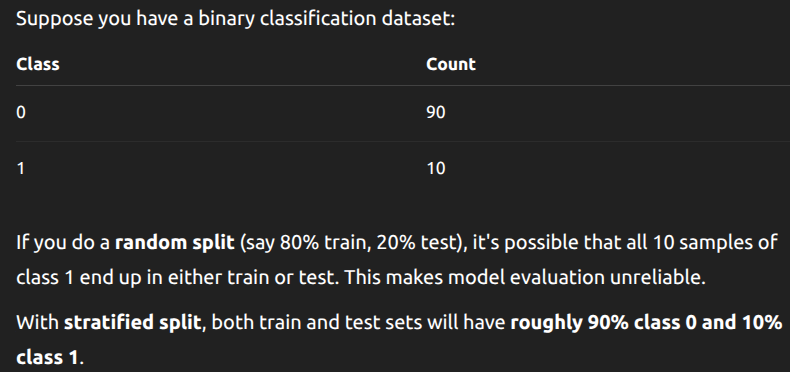

This is a good example if you wnat to understand what exaclty is stratifying in train test split

###Also before the training th emodel let's just go thru some accuracy metrics which we use to check the performance of model
- Confusion matrix: Also known as the error matrix, allows visualization of the performance of an algorithm:

  - True Positive (TP): Diabetic correctly identified as diabetic  
  - True Negative (TN): Healthy correctly identified as healthy  
  - False Positive (FP): Healthy incorrectly identified as diabetic  
  - False Negative (FN): Diabetic incorrectly identified as healthy  

- Metrics:

  - Accuracy: (TP + TN) / (TP + TN + FP + FN)  
  - Precision: TP / (TP + FP)  
  - Recall: TP / (TP + FN)  
  - F1 score: 2 x ((Precision x Recall) / (Precision + Recall))  

- ROC Curve: The ROC curve is created by plotting the true positive rate (TPR) against the false positive rate (FPR) at various threshold settings.

- Precision Recall Curve: Shows the tradeoff between precision and recall for different thresholds.



In [ ]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import lightgbm as lgbm
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.metrics import precision_score, roc_auc_score, recall_score, confusion_matrix, roc_curve, precision_recall_curve, accuracy_score
from scipy.stats import randint as sp_randint
from scipy.stats import uniform as sp_uniform
import warnings
import plotly.io as pio
pio.renderers.default = 'colab'
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff


In [ ]:
def model_performance(model) :
    #Conf matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    annotations = np.array([
        ["TN: {}".format(conf_matrix[0,0]), "FP: {}".format(conf_matrix[0,1])],
        ["FN: {}".format(conf_matrix[1,0]), "TP: {}".format(conf_matrix[1,1])]
    ])

    trace1 = go.Heatmap(
        z = conf_matrix,
        x = ["0 (pred)", "1 (pred)"],
        y = ["0 (true)", "1 (true)"],
        xgap = 2,
        ygap = 2,
        colorscale = 'Viridis',
        showscale = False,
        text = annotations,           # <-- show text inside each cell
        texttemplate = "%{text}",     # <-- tell Plotly to render it
        hoverinfo = "z"               # <-- optional: only show value on hover
    )
    #Show metrics
    tp = conf_matrix[1,1]
    fn = conf_matrix[1,0]
    fp = conf_matrix[0,1]
    tn = conf_matrix[0,0]
    Accuracy  =  ((tp+tn)/(tp+tn+fp+fn))
    Precision =  (tp/(tp+fp))
    Recall    =  (tp/(tp+fn))
    F1_score  =  (2*(((tp/(tp+fp))*(tp/(tp+fn)))/((tp/(tp+fp))+(tp/(tp+fn)))))

    show_metrics = pd.DataFrame(data=[[Accuracy , Precision, Recall, F1_score]])
    show_metrics = show_metrics.T

    colors = ['gold', 'lightgreen', 'lightcoral', 'lightskyblue']
    trace2 = go.Bar(x = (show_metrics[0].values),
                   y = ['Accuracy', 'Precision', 'Recall', 'F1_score'], text = np.round(show_metrics[0].values,4),
                    textposition = 'auto',
                   orientation = 'h', opacity = 0.8,marker=dict(
            color=colors,
            line=dict(color='#000000',width=1.5)))

    #Roc curve
    model_roc_auc = round(roc_auc_score(y_test, y_score) , 3)
    fpr, tpr, t = roc_curve(y_test, y_score)
    trace3 = go.Scatter(x = fpr,y = tpr,
                        name = "Roc : " + str(model_roc_auc),
                        line = dict(color = ('rgb(22, 96, 167)'),width = 2), fill='tozeroy')
    trace4 = go.Scatter(x = [0,1],y = [0,1],
                        line = dict(color = ('black'),width = 1.5,
                        dash = 'dot'))

    # Precision-recall curve
    precision, recall, thresholds = precision_recall_curve(y_test, y_score)
    trace5 = go.Scatter(x = recall, y = precision, name = "Precision" + str(precision), line = dict(color = ('lightcoral'),width = 2), fill='tozeroy')

    #Feature importance
    coefficients  = pd.DataFrame(eval(model).feature_importances_)
    column_data   = pd.DataFrame(list(df))
    coef_sumry    = (pd.merge(coefficients,column_data,left_index= True,
                              right_index= True, how = "left"))
    coef_sumry.columns = ["coefficients","features"]
    coef_sumry    = coef_sumry.sort_values(by = "coefficients",ascending = False)
    coef_sumry = coef_sumry[coef_sumry["coefficients"] !=0]
    trace6 = go.Bar(x = coef_sumry["features"],y = coef_sumry["coefficients"],
                    name = "coefficients",
                    marker = dict(color = coef_sumry["coefficients"],
                                  colorscale = "Viridis",
                                  line = dict(width = .6,color = "black")))

    #Cumulative gain
    pos = pd.get_dummies(y_test).values
    pos = pos[:,1]
    npos = np.sum(pos)
    index = np.argsort(y_score)
    index = index[::-1]
    sort_pos = pos[index]
    #cumulative sum
    cpos = np.cumsum(sort_pos)
    #recall
    recall = cpos/npos
    #size obs test
    n = y_test.shape[0]
    size = np.arange(start=1,stop=369,step=1)
    #proportion
    size = size / n
    #plots
    model = model
    trace7 = go.Scatter(x = size,y = recall,
                        name = "Lift curve",
                        line = dict(color = ('gold'),width = 2), fill='tozeroy')

    #Subplots
    fig = make_subplots(rows=4, cols=2, print_grid=False,
                          specs=[[{}, {}],
                                 [{}, {}],
                                 [{'colspan': 2}, None],
                                 [{'colspan': 2}, None]],
                          subplot_titles=('Confusion Matrix (1- fraud, 0 - nonfraud)',
                                        'Metrics',
                                        'ROC curve'+" "+ '('+ str(model_roc_auc)+')',
                                        'Precision - Recall curve',
                                        'Cumulative gains curve',
                                        'Feature importance',
                                        ))

    fig.append_trace(trace1,1,1)
    fig.append_trace(trace2,1,2)
    fig.append_trace(trace3,2,1)
    fig.append_trace(trace4,2,1)
    fig.append_trace(trace5,2,2)
    fig.append_trace(trace6,4,1)
    fig.append_trace(trace7,3,1)

    fig['layout'].update(showlegend = False, title = '<b>Model performance report</b><br>'+str(model),
                        autosize = False, height = 1500,width = 830,
                        plot_bgcolor = 'rgba(240,240,240, 0.95)',
                        paper_bgcolor = 'rgba(240,240,240, 0.95)',
                        margin = dict(b = 195))
    fig["layout"]["xaxis2"].update((dict(range=[0, 1])))
    fig["layout"]["xaxis3"].update(dict(title = "false positive rate"))
    fig["layout"]["yaxis3"].update(dict(title = "true positive rate"))
    fig["layout"]["xaxis4"].update(dict(title = "recall"), range = [0,1.05])
    fig["layout"]["yaxis4"].update(dict(title = "precision"), range = [0,1.05])
    fig["layout"]["xaxis5"].update(dict(title = "Percentage contacted"))
    fig["layout"]["yaxis5"].update(dict(title = "Percentage positive targeted"))
    fig.layout.titlefont.size = 14

    fig.show()

###Using Light GBM without using randomized seaarch Cv where randomisedsearchcv is an algorithm that can be used to tune the hyperparameters
It helps you find the best combination of hyperparameters for a model by randomly sampling from a given parameter grid.



In [ ]:
lgbm_clf = lgbm.LGBMClassifier(n_estimators=100)

lgbm_clf.fit(x_train, y_train)
y_pred = lgbm_clf.predict(x_test)
y_score = lgbm_clf.predict_proba(x_test)[:,1]

In [ ]:
model_performance('lgbm_clf')

LightGBM : Hyperparameters :

- learning_rate : This determines the impact of each tree on the final outcome. GBM works by starting with an initial estimate which is updated using the output of each tree. The learning parameter controls the magnitude of this change in the estimates
- n_estimators : number of trees (or rounds)
- num_leaves : number of leaves in full tree, default: 31
- min_child_samples : minimal number of data in one leaf. Can be used to deal with over-fitting
- min_child_weight : minimal sum hessian in one leaf.
- subsample : randomly select part of data without resampling
- max_depth : It describes the maximum depth of tree. This parameter is used to handle model overfitting.
- colsample_bytree : LightGBM will randomly select part of features on each iteration if colsample_bytree smaller than 1.0. For example, if you set it to 0.8, LightGBM will select 80% of features before training each tree
- reg_alpha : regularization
- reg_lambda : regularization

- early_stopping_rounds : This parameter can help you speed up your analysis. Model will stop training if one metric of one validation data doesn’t improve in last early_stopping_round rounds. This will reduce excessive iterations

In [ ]:
fit_params = {"early_stopping_rounds" : 50,
             "eval_metric" : 'binary',
             "eval_set" : [(x_test,y_test)],
             'eval_names': ['valid'],
             'verbose': 0,
             'categorical_feature': 'auto'}

param_test = {'learning_rate' : [0.01, 0.02, 0.03, 0.04, 0.05, 0.08, 0.1, 0.2, 0.3, 0.4],
              'n_estimators' : [100, 200, 300, 400, 500, 600, 800, 1000, 1500, 2000, 3000, 5000],
              'num_leaves': sp_randint(6, 50),
              'min_child_samples': sp_randint(100, 500),
              'min_child_weight': [1e-5, 1e-3, 1e-2, 1e-1, 1, 1e1, 1e2, 1e3, 1e4],
              'subsample': sp_uniform(loc=0.2, scale=0.8),
              'max_depth': [-1, 1, 2, 3, 4, 5, 6, 7],
              'colsample_bytree': sp_uniform(loc=0.4, scale=0.6),
              'reg_alpha': [0, 1e-1, 1, 2, 5, 7, 10, 50, 100],
              'reg_lambda': [0, 1e-1, 1, 5, 10, 20, 50, 100]}

#number of combinations
n_iter = 5

#intialize lgbm and do the search for best hyper parametrs
lgbm_clf = lgbm.LGBMClassifier(verbosity=-1, metric='None', n_jobs=4)
grid_search = RandomizedSearchCV(
    estimator=lgbm_clf, param_distributions=param_test,
    n_iter=n_iter,
    scoring='f1',
    cv=5,
    refit=True,
    verbose=True)

grid_search.fit(
    x_train,
    y_train,
    eval_set=[(x_test, y_test)],
    eval_metric='binary_logloss',
    # early_stopping_rounds=50,
    # verbose=0
)

print('Best score reached: {} with params: {} '.format(grid_search.best_score_, grid_search.best_params_))

opt_parameters =  grid_search.best_params_

clf_sw = lgbm.LGBMClassifier(**lgbm_clf.get_params())
#Optimal parameter
clf_sw.set_params(**opt_parameters)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best score reached: 0.8631867700496342 with params: {'colsample_bytree': np.float64(0.6858705256137274), 'learning_rate': 0.1, 'max_depth': 2, 'min_child_samples': 153, 'min_child_weight': 0.001, 'n_estimators': 2000, 'num_leaves': 40, 'reg_alpha': 5, 'reg_lambda': 10, 'subsample': np.float64(0.6708104733648426)} 


LGBMClassifier(colsample_bytree=np.float64(0.6858705256137274), max_depth=2,
               metric='None', min_child_samples=153, n_estimators=2000,
               n_jobs=4, num_leaves=40, reg_alpha=5, reg_lambda=10,
               subsample=np.float64(0.6708104733648426), verbosity=-1)

####So as we have got our tuned paramters

In [ ]:
lgbm_clf = lgbm.LGBMClassifier(colsample_bytree=np.float64(0.6858705256137274), max_depth=2,
               metric='None', min_child_samples=153, n_estimators=2000,
               n_jobs=4, num_leaves=40, reg_alpha=5, reg_lambda=10,
               subsample=np.float64(0.6708104733648426), verbosity=-1)

In [ ]:
lgbm_clf.fit(x_train, y_train)
y_pred = lgbm_clf.predict(x_test)
y_score = lgbm_clf.predict_proba(x_test)[:,1]

In [ ]:
model_performance('lgbm_clf')